In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("D:/PROJECT/NETWORK ANOMALY DETECTION/preprocessed_data.csv")

In [22]:
display(df.head())

,Unnamed: 0,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,...,packet_size frequency_band_energy,inter_arrival_time packet_count_5s,inter_arrival_time spectral_entropy,inter_arrival_time frequency_band_energy,packet_count_5s spectral_entropy,packet_count_5s frequency_band_energy,spectral_entropy frequency_band_energy,SYN_ACK_ratio,FIN_SYN_ratio,TCP_vs_UDP
0,0,0.405154,0.620362,62569,443,0.857143,0.834066,0.534891,0.0,0,...,0.216713,0.531739,0.517423,0.331826,0.714914,0.458478,0.446134,0.0,0.0,0.0
1,1,0.527559,0.741288,59382,443,0.785714,0.147196,0.990757,0.0,0,...,0.522683,0.582440,0.109114,0.734436,0.115654,0.778452,0.145835,0.0,0.0,0.0
2,2,0.226199,0.485116,65484,80,0.285714,0.855192,0.031781,0.0,0,...,0.007189,0.138605,0.414867,0.015418,0.244341,0.009080,0.027179,0.0,0.0,0.0
3,3,0.573372,0.450965,51707,53,0.142857,0.153220,0.169958,0.0,0,...,0.097449,0.064424,0.069097,0.076645,0.021889,0.024280,0.026041,0.0,0.0,0.0
4,4,0.651396,0.888740,26915,53,0.714286,0.923916,0.552053,0.0,1,...,0.359605,0.634814,0.821121,0.490632,0.659940,0.394324,0.510051,0.0,0.0,1.0


In [23]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Shape: (1000, 44)

Data Types:
 Unnamed: 0                                    int64
packet_size                                 float64
inter_arrival_time                          float64
src_port                                      int64
dst_port                                      int64
packet_count_5s                             float64
spectral_entropy                            float64
frequency_band_energy                       float64
label                                       float64
protocol_type_TCP                             int64
protocol_type_UDP                             int64
src_ip_192.168.1.2                            int64
src_ip_192.168.1.3                            int64
dst_ip_192.168.1.5                            int64
dst_ip_192.168.1.6                            int64
tcp_flags_FIN                                 int64
tcp_flags_SYN                                 int64
tcp_flags_SYN-ACK                             int64
packet_size_log                 

In [24]:
display(df.describe(include='all'))


,Unnamed: 0,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,...,packet_size frequency_band_energy,inter_arrival_time packet_count_5s,inter_arrival_time spectral_entropy,inter_arrival_time frequency_band_energy,packet_count_5s spectral_entropy,packet_count_5s frequency_band_energy,spectral_entropy frequency_band_energy,SYN_ACK_ratio,FIN_SYN_ratio,TCP_vs_UDP
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,0.502446,0.512259,32024.617000,199.769000,0.506857,0.495222,0.485651,0.10000,0.311000,...,0.239325,0.258844,0.253457,0.244282,0.250227,0.243667,0.244290,0.255000,0.251000,0.311000
std,288.819436,0.289606,0.281130,18520.890349,180.078488,0.303271,0.292927,0.295953,0.30015,0.463134,...,0.215069,0.228484,0.219943,0.213197,0.227932,0.227042,0.227063,0.436079,0.433805,0.463134
min,0.000000,0.000000,0.000000,1038.000000,53.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,249.750000,0.256263,0.275909,16245.250000,53.000000,0.267857,0.236912,0.228039,0.00000,0.000000,...,0.064579,0.065703,0.069429,0.068012,0.062957,0.059612,0.054859,0.000000,0.000000,0.000000
50%,499.500000,0.499642,0.515971,31883.000000,80.000000,0.500000,0.504290,0.467905,0.00000,0.000000,...,0.179102,0.197843,0.188010,0.186575,0.189140,0.172850,0.176074,0.000000,0.000000,0.000000
75%,749.250000,0.741410,0.746523,47746.250000,443.000000,0.785714,0.761556,0.750876,0.00000,1.000000,...,0.358871,0.401296,0.396115,0.374404,0.380713,0.385042,0.382254,1.000000,1.000000,1.000000
max,999.000000,1.000000,1.000000,65484.000000,443.000000,1.000000,1.000000,1.000000,1.00000,1.000000,...,0.971347,0.962817,0.935101,0.947695,0.971505,0.986927,0.944450,1.000000,1.000000,1.000000


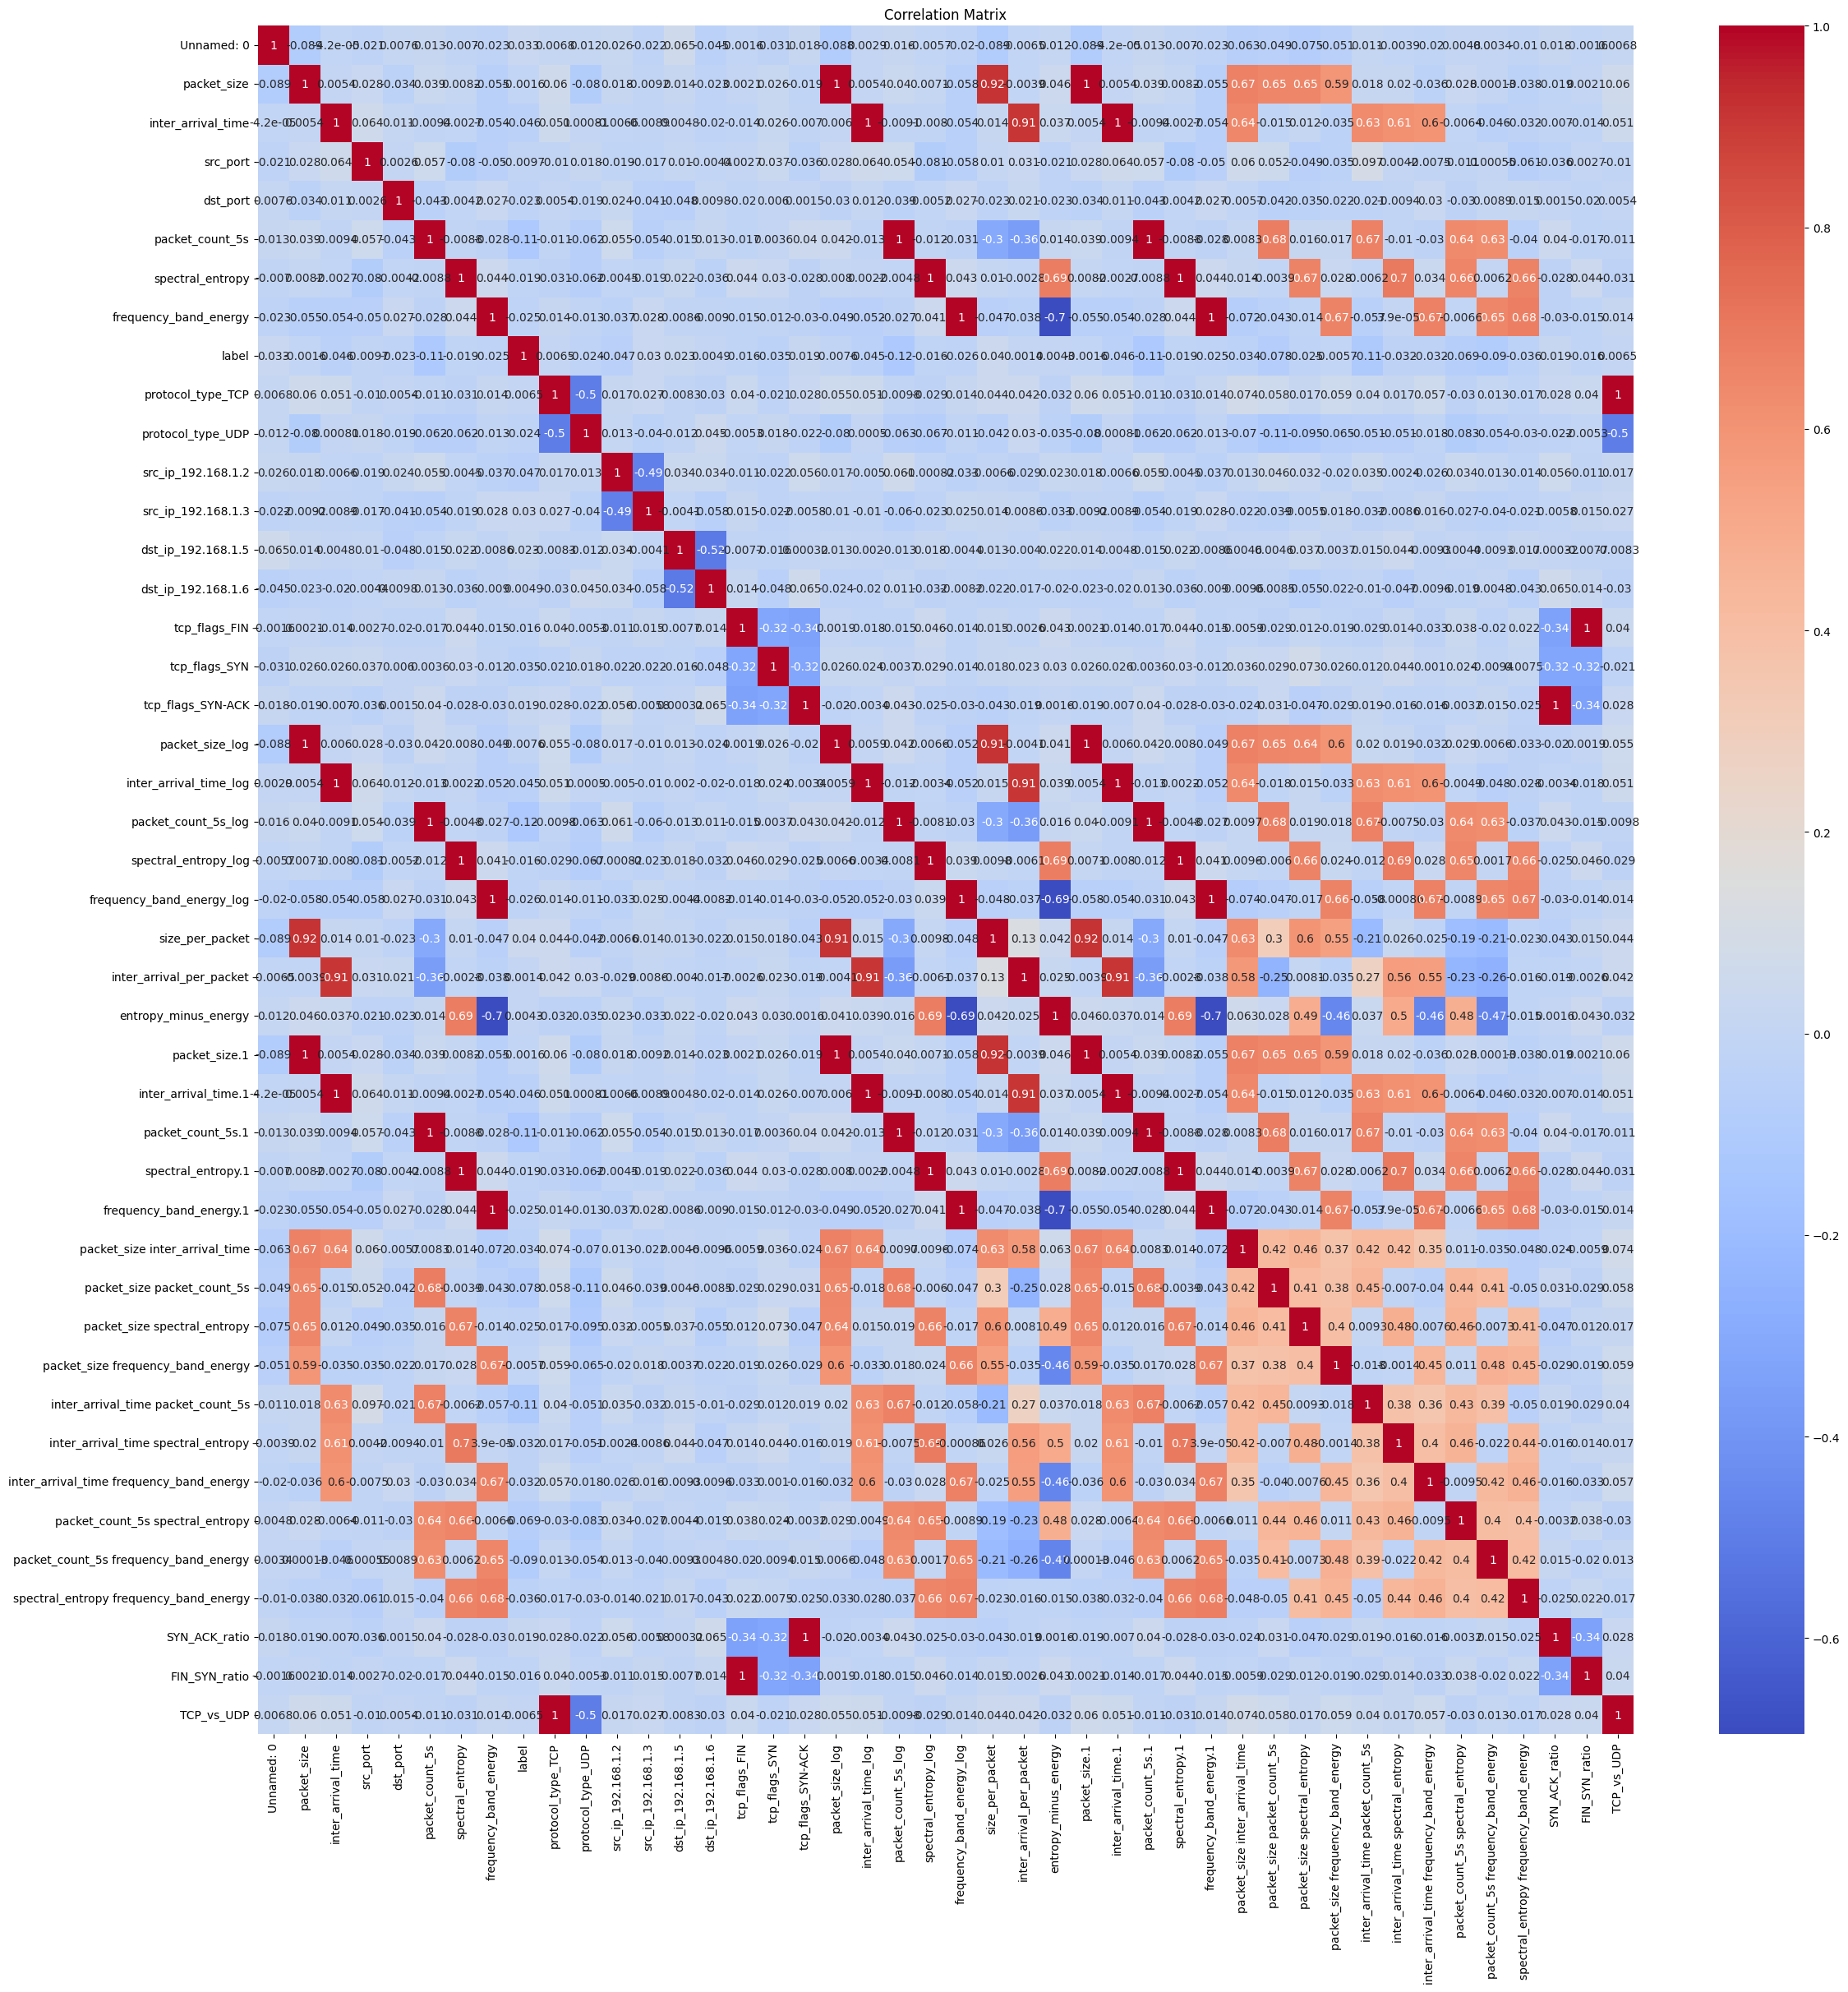

In [31]:
plt.figure(figsize=(27,27))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

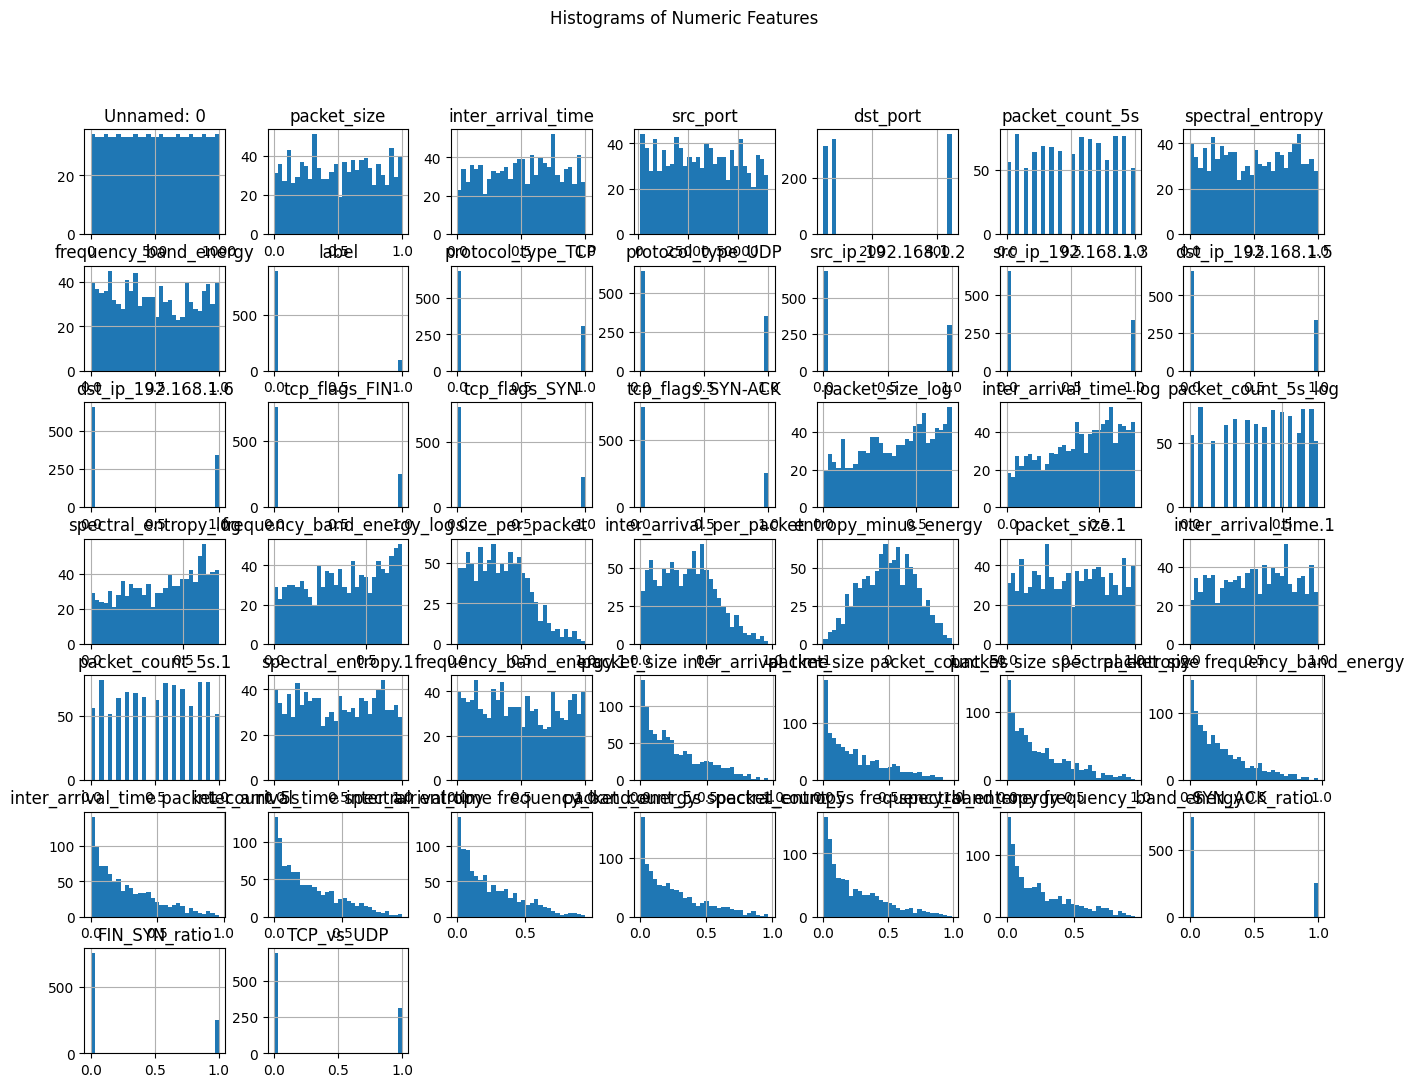

In [32]:
df.hist(figsize=(16,12), bins=30)
plt.suptitle("Histograms of Numeric Features")
plt.show()